In [83]:
# install requirements once
import pickle
import os
from mistralai import Mistral
import time
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [21]:
with open('merged_all_added_score.pkl', 'rb') as f:
    df = pickle.load(f)
df

,page_id,pagenumber,publication_date,place_of_distribution,language,plainpagefulltext,paper_title,score
0,UYPNVCGFNZRHE4VD4AV6LMBHODX7QDNA-FILE_0007_DDB...,7,1940-09-19 12:00:00,[Stuttgart],[ger],"fft, M — Schwäbischer Merkllr 3 Stuttgart — Do...",Schwäbischer Merkur : mit Schwäbischer Kronik ...,1
1,5HNZ7CKJA23HRQVLH775UJINWQOLPLIT-FILE_0002_DDB...,2,1940-09-26 12:00:00,[Stuttgart],[ger],Nr. 226 — Schwäbischer Merkm Stuttgart — Donne...,Schwäbischer Merkur : mit Schwäbischer Kronik ...,0
2,GTY6WLKCOIUQUTROD5AIF7YCHNQ25ITJ-FILE_0006_DDB...,6,1940-09-09 12:00:00,[Stuttgart],[ger],"8 Handelszeitung des Schwäbischen Merkur, Stut...",Schwäbischer Merkur : mit Schwäbischer Kronik ...,0
3,JDRB3HLYATIXKFNZ4SY2IFFE6BI5SW6I-FILE_0005_DDB...,5,1940-09-18 12:00:00,[Stuttgart],[ger],"7 Schwäbischer Merkur (Schwäbische Kronik), St...",Schwäbischer Merkur : mit Schwäbischer Kronik ...,0
4,VKUSW5DUFUGFJCRQOJJWQU4EQP4RSZWV-FILE_0004_DDB...,4,1940-09-16 12:00:00,[Stuttgart],[ger],"Nr. 217 — Schwäbischer Merkur Frage, bi« Mater...",Schwäbischer Merkur : mit Schwäbischer Kronik ...,1
...,...,...,...,...,...,...,...,...
104031,OOYZ4LFEAKZJG6YIZB7VSYCKQYNIOKO2-FILE_0010_DDB...,10,1934-01-10 12:00:00,[Stuttgart],[ger],Nr. 6 — Seite 10 die Entwicklung der Vmeätxe l...,Schwäbischer Merkur : mit Schwäbischer Kronik ...,0
104032,4M6YGR5JQA33FK62Q2UJNHILZQQHDC5G-FILE_0002_DDB...,2,1934-01-30 12:00:00,[Stuttgart],[ger],"SLllMWr Werter Dtmstag 30, Sanvar 1934 — Nr. z...",Schwäbischer Merkur : mit Schwäbischer Kronik ...,2
104033,7ZFSURJJ5HU2VCOIJJII7NPLHUIVV5QW-FILE_0007_DDB...,7,1934-01-17 12:00:00,[Stuttgart],[ger],7 BiWöifdier Merkur und vom tt auch ein stille...,Schwäbischer Merkur : mit Schwäbischer Kronik ...,1
104034,2MWQKNRRCYTBWSFYXYAXWGCIQMKDRRZG-FILE_0007_DDB...,7,1934-01-24 12:00:00,[Stuttgart],[ger],n 4 eWIfdjtr MerbU lebenribejahenLem Ginn« dur...,Schwäbischer Merkur : mit Schwäbischer Kronik ...,0


In [22]:
df['paper_title'].unique()

array(['Schwäbischer Merkur : mit Schwäbischer Kronik und Handelszeitung : Süddeutsche Zeitung',
       'Hamburger Tageblatt : Zeitung der Nationalsozialistischen Deutschen Arbeiterpartei',
       'Vorwärts'], dtype=object)

In [23]:
df_tmp =df[df['score']!=""]
df_tmp['paper_title'].unique()


len(df)

25234

In [24]:
df_tmp = df[df['score'].astype(str).str.len() <= 5]
df_tmp_bigger = df[df['score'].astype(str).str.len() > 5]
len(df_tmp_bigger)

67

In [25]:
df_tmp = df_tmp[df_tmp['score'].isin(['1', '0', '-1', '2', '1.5', '-2','-1.6'])]
df_tmp['score'] = df_tmp['score'].astype(float)
#df_tmp = df_tmp[df_tmp['score']==0]

print(len(df_tmp[df_tmp['paper_title']=='Schwäbischer Merkur : mit Schwäbischer Kronik und Handelszeitung : Süddeutsche Zeitung']))
print(len(df_tmp[df_tmp['paper_title']=='Hamburger Tageblatt : Zeitung der Nationalsozialistischen Deutschen Arbeiterpartei']))
print(len(df_tmp[df_tmp['paper_title']=='Vorwärts']))

#len(df_filtered[df_filtered['paper_title']=='Schwäbischer Merkur : mit Schwäbischer Kronik und Handelszeitung : Süddeutsche Zeitung'])

11032
8031
6101


In [26]:
print(df_tmp[df_tmp['score'] > 1.8]
      .sample(n=1, random_state=4)['plainpagefulltext']
      .values[0][:500])


2. Ausgabe Hamburger Tageblatt ZEITUNG DER NATIONALSOZIALISTISCHEN DEUTSCHEN ARBEITERPARTEI Hamburg, Freitag, 1. Mai 1942 Einzelpreis 15 Pfg., auswärts 20 Ptg. Heupteehrlftleiter: Max Baumann. Hamburg. Telephonruf: 32 10 04 Telegramme: Tageblatt. Fernschreiber: Hamburg 02 1231 und 021242. Bezugspreise; Durch Boten monatlich RM 2.36 elnschUeOlich 30 Pfg Vertriebsstellengebühr und Trägerlohn, halbmonat lich RM 1.20 einschließlich 24 Ptg. Vertriebsstellengebühr und Trägerlohn: durch die Post monatl


C:\Users\finke\AppData\Local\Temp\ipykernel_32348\3424459124.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\finke\AppData\Local\Temp\ipykernel_32348\3424459124.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\finke\AppData\Local\Temp\ipykernel_32348\3424459124.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

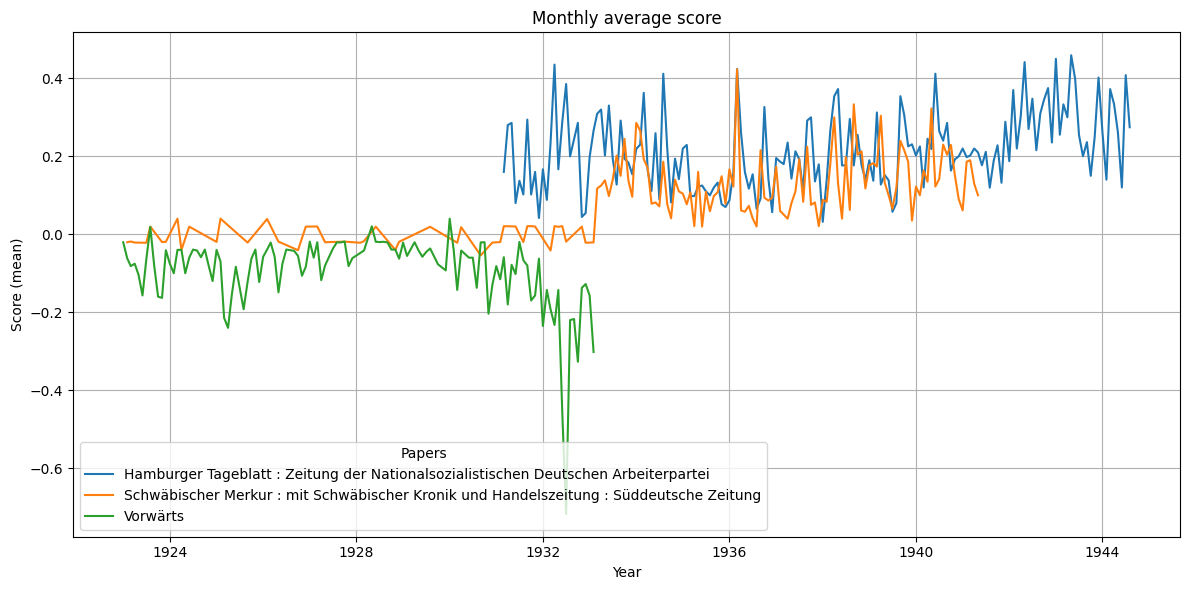

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter gültiger Scores
df_tmp = df[df['score'].isin(['1', '0', '-1', '2', '1.5', '-2','-1.6'])]
df_tmp['score'] = df_tmp['score'].astype(float)
df_tmp['publication_date'] = pd.to_datetime(df_tmp['publication_date'], errors='coerce')

# Gruppieren nach Titel, Woche und mittlerem Score
df_tmp['date_flag'] = df_tmp['publication_date'].dt.to_period('M').dt.start_time

mean_scores = (
    df_tmp.groupby(['paper_title', 'date_flag'])['score']
    .mean()
    .reset_index()
    .sort_values(by=['paper_title', 'date_flag'])
)

# Nur Scores ≠ 0 plotten
score_grouped_tmp = mean_scores[mean_scores['score'] != 0]

# Plot
plt.figure(figsize=(12, 6))

for title in score_grouped_tmp['paper_title'].unique():
    df_paper = score_grouped_tmp[score_grouped_tmp['paper_title'] == title]
    plt.plot(df_paper['date_flag'], df_paper['score'], label=title)

plt.title('Monthly average score')
plt.xlabel('Year')
plt.ylabel('Score (mean)')
plt.legend(title='Papers')
plt.grid(True)
plt.tight_layout()
plt.savefig('monthly_average_score_plot.svg')
plt.show()


C:\Users\finke\AppData\Local\Temp\ipykernel_6368\670730923.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\finke\AppData\Local\Temp\ipykernel_6368\670730923.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\finke\AppData\Local\Temp\ipykernel_6368\670730923.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

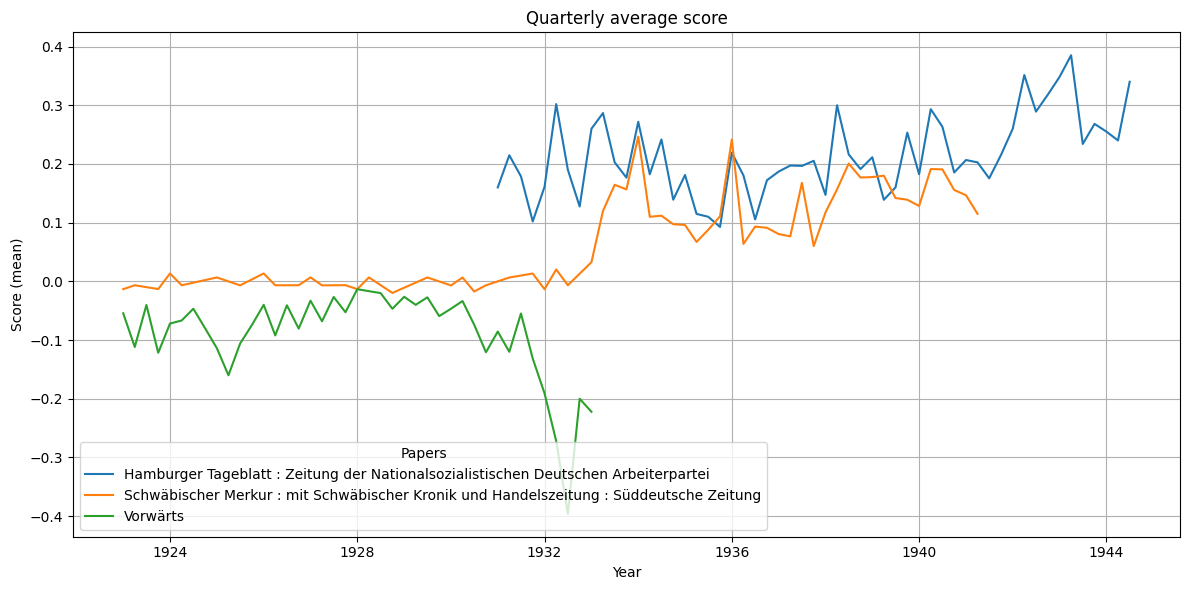

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter gültiger Scores
df_tmp = df[df['score'].isin(['1', '0', '-1', '2', '1.5', '-2','-1.6'])]
df_tmp['score'] = df_tmp['score'].astype(float)
df_tmp['publication_date'] = pd.to_datetime(df_tmp['publication_date'], errors='coerce')

# Gruppieren nach Titel, Woche und mittlerem Score
df_tmp['date_flag'] = df_tmp['publication_date'].dt.to_period('Q').dt.start_time

mean_scores = (
    df_tmp.groupby(['paper_title', 'date_flag'])['score']
    .mean()
    .reset_index()
    .sort_values(by=['paper_title', 'date_flag'])
)

# Nur Scores ≠ 0 plotten
score_grouped_tmp = mean_scores[mean_scores['score'] != 0]

# Plot
plt.figure(figsize=(12, 6))

for title in score_grouped_tmp['paper_title'].unique():
    df_paper = score_grouped_tmp[score_grouped_tmp['paper_title'] == title]
    plt.plot(df_paper['date_flag'], df_paper['score'], label=title)

plt.title('Quarterly average score')
plt.xlabel('Year')
plt.ylabel('Score (mean)')
plt.legend(title='Papers')
plt.grid(True)
plt.tight_layout()
plt.savefig('quarterly_average_score_plot.svg')
plt.show()


In [57]:
import pandas as pd
import plotly.express as px

# Filter gültiger Scores
df_tmp = df[df['score'].isin(['1', '0', '-1', '2', '1.5', '-2', '-1.6'])]

df_tmp = df_tmp.replace("Schwäbischer Merkur : mit Schwäbischer Kronik und Handelszeitung : Süddeutsche Zeitung", "Schwäbischer Merkur") 
df_tmp = df_tmp.replace("Hamburger Tageblatt : Zeitung der Nationalsozialistischen Deutschen Arbeiterpartei", "Hamburger Tageblatt") 

df_tmp['score'] = df_tmp['score'].astype(float)
df_tmp['publication_date'] = pd.to_datetime(df_tmp['publication_date'], errors='coerce')

df_tmp

# Gruppieren nach Titel, Monat und mittlerem Score
df_tmp['month'] = df_tmp['publication_date'].dt.to_period('M').dt.start_time

monthly_mean_scores = (
    df_tmp.groupby(['paper_title', 'month'])['score']
    .mean()
    .reset_index()
    .sort_values(by=['paper_title', 'month'])
)

# Nur Scores ≠ 0 plotten
score_grouped_tmp = monthly_mean_scores[monthly_mean_scores['score'] != 0]

# Plot mit Plotly
fig = px.line(
    score_grouped_tmp,
    x='month',
    y='score',
    color='paper_title',
    labels={
        'month': 'Year',
        'score': 'Score (mean)',
        'paper_title': 'Papers'
    },
    title='Quarterly average score'
)

fig.update_layout(
    xaxis=dict(title='Year'),
    yaxis=dict(title='Score (mean)'),
    legend_title='Newspapers',
    #template='simple_white',
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',

    legend=dict(
    orientation="h",
    entrywidth=160,
    yanchor="bottom",
    y=1.02,
    xanchor="right",
    x=1
))



fig.write_html("average_score_plot.html")


In [92]:


# ------- Events vorbereiten -------
# df_events: Spalten ['event','label','date'] wie in deinem Beispiel
df_events = pd.read_csv("wikidata_events.csv", encoding="utf-8", sep=";")
#df_events = df_events.drop_duplicates(subset=['event'])

df_events["date"] = pd.to_datetime(df_events["date"], errors="coerce")

df_events = df_events[
    ~((df_events["date"].dt.month == 1) & (df_events["date"].dt.day == 1))
]

# Filter gültiger Scores
df_tmp = df[df['score'].isin(['1', '0', '-1', '2', '1.5', '-2', '-1.6'])]

df_tmp = df_tmp.replace("Schwäbischer Merkur : mit Schwäbischer Kronik und Handelszeitung : Süddeutsche Zeitung", "Schwäbischer Merkur") 
df_tmp = df_tmp.replace("Hamburger Tageblatt : Zeitung der Nationalsozialistischen Deutschen Arbeiterpartei", "Hamburger Tageblatt") 

df_tmp['score'] = df_tmp['score'].astype(float)
df_tmp['publication_date'] = pd.to_datetime(df_tmp['publication_date'], errors='coerce')

df_tmp

# Gruppieren nach Titel, Monat und mittlerem Score
df_tmp['month'] = df_tmp['publication_date'].dt.to_period('M').dt.start_time

monthly_mean_scores = (
    df_tmp.groupby(['paper_title', 'month'])['score']
    .mean()
    .reset_index()
    .sort_values(by=['paper_title', 'month'])
)

# Nur Scores ≠ 0 plotten
score_grouped_tmp = monthly_mean_scores[monthly_mean_scores['score'] != 0]


# Plot mit Plotly
fig = px.line(
    score_grouped_tmp,
    x='month',
    y='score',
    color='paper_title',
    labels={
        'month': 'Year',
        'score': 'Score (mean)',
        'paper_title': 'Papers'
    },
    title='Quarterly average score'
)

for row in df_events.itertuples(index=False):
    x = row.date

    # Vertical line behind the traces
    fig.add_shape(
        type="line",
        x0=x, x1=x,
        y0=0, y1=1,           # full height
        yref="paper",         # use paper coords so it spans the plot
        layer="below",
        line=dict(color="gray", width=1, dash="dot")
    )

    # Rotated label at the top
    fig.add_annotation(
        x=x, xref="x",
        y=0, yref="paper",        # bottom of plotting area
        yanchor="bottom",         # text grows upward from the bottom
        text=f'<a href="{row.event}" target="_blank">{row.label}</a>',
        showarrow=False,
        textangle=90,             # keep vertical; set to 0 for horizontal
        xanchor="left",
        yshift=4,                 # tiny lift so it’s not on the axis line
        bgcolor="rgba(255,255,255,0.7)",
        bordercolor="gray",
        borderwidth=0.5,
        font=dict(size=10)
    )
    
fig.update_layout(hovermode="x unified")
fig.update_layout(
    xaxis=dict(title='Year'),
    yaxis=dict(title='Score (mean)'),
    legend_title='Newspapers',
    #template='simple_white',
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',

    legend=dict(
    orientation="h",
    entrywidth=160,
    yanchor="bottom",
    y=1.02,
    xanchor="right",
    x=1
))



fig.write_html("average_score_plot.html")


In [93]:
df_events

,event,label,date
0,http://www.wikidata.org/entity/Q706684,Reichspräsidentenwahl 1932,1932-04-10 00:00:00+00:00
1,http://www.wikidata.org/entity/Q2021949,Großer Preis von Deutschland 1932,1932-07-17 00:00:00+00:00
2,http://www.wikidata.org/entity/Q2021949,Großer Preis von Deutschland 1932,1932-07-17 00:00:00+00:00
3,http://www.wikidata.org/entity/Q1498481,Geheimtreffen vom 20. Februar 1933,1933-02-20 00:00:00+00:00
19,http://www.wikidata.org/entity/Q638482,UCI-Straßen-Weltmeisterschaften 1934,1934-08-18 00:00:00+00:00
20,http://www.wikidata.org/entity/Q4305909,Volksabstimmung über das Staatsoberhaupt des D...,1934-08-19 00:00:00+00:00
21,http://www.wikidata.org/entity/Q389024,Reichstagswahl im Deutschen Reich 1936,1936-03-29 00:00:00+00:00
22,http://www.wikidata.org/entity/Q389024,Reichstagswahl im Deutschen Reich 1936,1936-03-29 00:00:00+00:00
23,http://www.wikidata.org/entity/Q1532978,Septemberverschwörung,1938-09-01 00:00:00+00:00
24,http://www.wikidata.org/entity/Q2378829,Deutsch-sowjetische Siegesparade in Brest-Litowsk,1939-09-22 00:00:00+00:00


In [50]:
def detect_outliers(group):
    mu = group['score'].mean()
    sigma = group['score'].std()
    threshold_upper = mu + 2.0 * sigma
    threshold_lower = mu - 2.0 * sigma
    
    group['is_outlier'] = (group['score'] > threshold_upper) | (group['score'] < threshold_lower)
    group['mu'] = mu
    group['sigma'] = sigma
    group['upper_threshold'] = threshold_upper
    group['lower_threshold'] = threshold_lower
    return group

outliers_df = mean_scores.groupby('paper_title', group_keys=False).apply(detect_outliers)

# Nur die Ausreißer anzeigen
outliers_only = outliers_df[outliers_df['is_outlier']]

outliers_only

unique_months = outliers_only["date_flag"].dt.strftime("%Y-%m").unique().tolist()
unique_months




C:\Users\finke\AppData\Local\Temp\ipykernel_32348\904892913.py:14: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



['1932-04',
 '1932-09',
 '1934-08',
 '1936-03',
 '1940-06',
 '1942-05',
 '1943-01',
 '1943-05',
 '1933-10',
 '1934-01',
 '1934-02',
 '1938-04',
 '1938-09',
 '1939-04',
 '1939-09',
 '1940-05',
 '1932-06',
 '1932-07',
 '1932-10',
 '1933-02']